In [ ]:
import pandas as pd
import numpy as np
import sklearn

df = pd.read_csv("results.csv")
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [ ]:
df.info

<bound method DataFrame.info of              date home_team   away_team  home_score  away_score  \
0      1872-11-30  Scotland     England         0.0         0.0   
1      1873-03-08   England    Scotland         4.0         2.0   
2      1874-03-07  Scotland     England         2.0         1.0   
3      1875-03-06   England    Scotland         2.0         2.0   
4      1876-03-04  Scotland     England         3.0         0.0   
...           ...       ...         ...         ...         ...   
49472  2026-06-27    Jordan   Argentina         NaN         NaN   
49473  2026-06-27  Colombia    Portugal         NaN         NaN   
49474  2026-06-27  DR Congo  Uzbekistan         NaN         NaN   
49475  2026-06-27    Panama     England         NaN         NaN   
49476  2026-06-27   Croatia       Ghana         NaN         NaN   

           tournament             city        country  neutral  
0            Friendly          Glasgow       Scotland    False  
1            Friendly           London        England    False  
2            Friendly          Glasgow       Scotland    False  
3            Friendly           London        England    False  
4            Friendly          Glasgow       Scotland    False  
...               ...              ...            ...      ...  
49472  FIFA World Cup        Arlington  United States     True  
49473  FIFA World Cup    Miami Gardens  United States     True  
49474  FIFA World Cup          Atlanta  United States     True  
49475  FIFA World Cup  East Rutherford  United States     True  
49476  FIFA World Cup     Philadelphia  United States     True  

[49477 rows x 9 columns]>

In [ ]:
df['goal_diff'] = df['home_score'] - df['away_score']
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,goal_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,2.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,0.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,3.0
...,...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,NaN
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,NaN
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True,NaN
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,NaN


In [ ]:
df = df.dropna(subset=["home_score", "away_score"])
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,goal_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,2.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,0.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,3.0
...,...,...,...,...,...,...,...,...,...,...
49408,2026-06-12,United States,Paraguay,4.0,1.0,FIFA World Cup,Inglewood,United States,False,3.0
49409,2026-06-13,Qatar,Switzerland,1.0,1.0,FIFA World Cup,Santa Clara,United States,True,0.0
49410,2026-06-13,Brazil,Morocco,1.0,1.0,FIFA World Cup,East Rutherford,United States,True,0.0
49411,2026-06-13,Haiti,Scotland,0.0,1.0,FIFA World Cup,Foxborough,United States,True,-1.0


In [ ]:
def get_result(row):
    if row["home_score"] > row["away_score"]:
      return "Home Win"
    elif row["home_score"] < row["away_score"]:
      return "Away Win"
    else:
      return "Draw"

df['result'] = df.apply(get_result, axis=1)
df


/tmp/ipykernel_7388/2599683689.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['result'] = df.apply(get_result, axis=1)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,goal_diff,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0.0,Draw
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,2.0,Home Win
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1.0,Home Win
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,0.0,Draw
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,3.0,Home Win
...,...,...,...,...,...,...,...,...,...,...,...
49408,2026-06-12,United States,Paraguay,4.0,1.0,FIFA World Cup,Inglewood,United States,False,3.0,Home Win
49409,2026-06-13,Qatar,Switzerland,1.0,1.0,FIFA World Cup,Santa Clara,United States,True,0.0,Draw
49410,2026-06-13,Brazil,Morocco,1.0,1.0,FIFA World Cup,East Rutherford,United States,True,0.0,Draw
49411,2026-06-13,Haiti,Scotland,0.0,1.0,FIFA World Cup,Foxborough,United States,True,-1.0,Away Win


In [ ]:
df["goal_diff"].describe()

,goal_diff
count,49413.000000
mean,0.575375
std,2.415815
min,-21.000000
25%,-1.000000
50%,0.000000
75%,2.000000
max,31.000000


In [ ]:
df["result"].value_counts()

,count
result,
Home Win,24216
Away Win,13961
Draw,11236


<Axes: xlabel='result'>

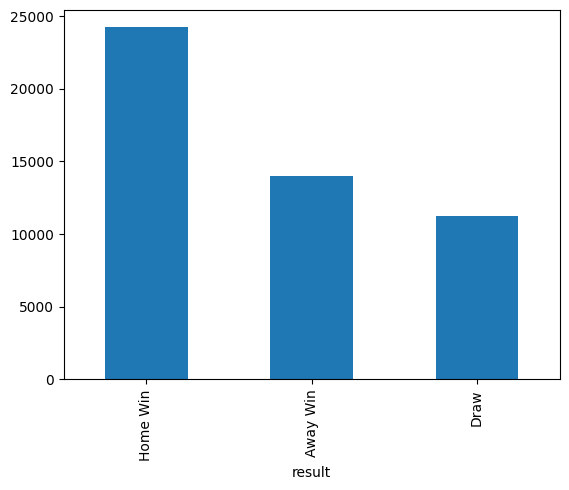

In [ ]:
df["result"].value_counts().plot(kind="bar")

In [ ]:
df['home_score'].mean()

np.float64(1.7572298787768401)

In [ ]:
df['away_score'].mean()

np.float64(1.181854977435088)

In [ ]:
df["tournament"].value_counts().head(10)

,count
tournament,
Friendly,18388
FIFA World Cup qualification,8771
UEFA Euro qualification,2824
African Cup of Nations qualification,2327
FIFA World Cup,972
Copa América,869
African Cup of Nations,845
AFC Asian Cup qualification,829
UEFA Nations League,658


In [ ]:
df["result"].value_counts(normalize=True) * 100


,proportion
result,
Home Win,49.007346
Away Win,28.253698
Draw,22.738955


In [ ]:
df[df['neutral']==False]['result'].value_counts(normalize=True)*100

,proportion
result,
Home Win,50.742779
Away Win,26.398900
Draw,22.858322


In [ ]:
df[df['neutral']==True]['result'].value_counts(normalize=True)*100

,proportion
result,
Home Win,44.178213
Away Win,33.414989
Draw,22.406798


playing at a non-neutral venue is associated with a higher probability of a home-team win.

<Axes: >

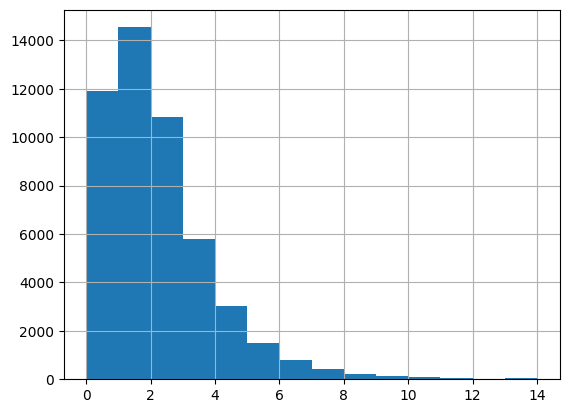

In [ ]:
df['home_score'].hist(bins=range(0, 15))

<Axes: >

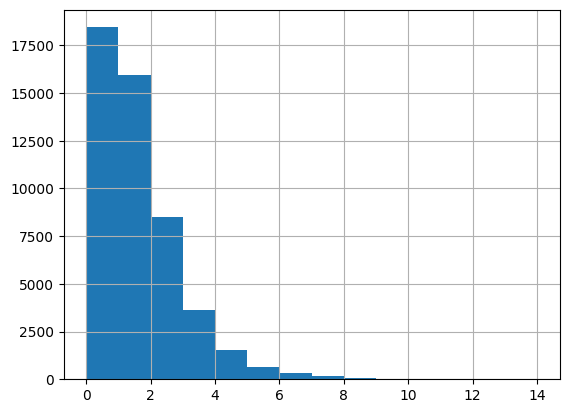

In [ ]:
df['away_score'].hist(bins=range(0, 15))

In [ ]:
df['home_score'].skew()

np.float64(2.22727776673419)

In [ ]:
df['away_score'].skew()

np.float64(2.540488000326387)

Away teams usually score very little, but occasionally score a lot. Right positive skew. Both home and away goal distributions exhibit strong positive skewness (2.23 and 2.54 respectively), indicating that low-scoring matches are common while high-scoring outcomes are relatively rare.

In [ ]:
tourn_stats = df.groupby("tournament")[
    ["home_score", "away_score"]
].mean()
tourn_stats

,home_score,away_score
tournament,,
ABCS Tournament,2.150000,1.550000
AFC Asian Cup,1.496437,1.161520
AFC Asian Cup qualification,2.208685,1.082027
AFC Challenge Cup,1.390805,1.241379
AFC Challenge Cup qualification,1.902174,1.141304
...,...,...
West African Cup,1.370370,1.259259
Windward Islands Tournament,1.762376,1.485149
World Unity Cup,1.000000,4.333333


In [ ]:
tourn_stats.loc['FIFA World Cup']

,FIFA World Cup
home_score,1.567901
away_score,1.250000


In [ ]:
home_stats= df.groupby('home_team').agg(
    home_goals_scored=('home_score', 'sum'),
    home_goals_conceded=('away_score', 'sum'),
    home_matches=('home_team', 'count')
)
home_stats

,home_goals_scored,home_goals_conceded,home_matches
home_team,,,
Abkhazia,42.0,13.0,23
Afghanistan,56.0,75.0,50
Albania,239.0,231.0,210
Alderney,20.0,199.0,48
Algeria,674.0,293.0,354
...,...,...,...
Yugoslavia,439.0,236.0,190
Zambia,626.0,284.0,332
Zanzibar,67.0,102.0,62


In [ ]:
away_stats= df.groupby('away_team').agg(
    away_goals_scored=('away_score', 'sum'),
    away_goals_conceded=('home_score', 'sum'),
    away_matches=('away_team', 'count')
)
away_stats

,away_goals_scored,away_goals_conceded,away_matches
away_team,,,
Abkhazia,12.0,13.0,10
Afghanistan,86.0,218.0,97
Albania,138.0,358.0,188
Alderney,53.0,421.0,87
Algeria,279.0,320.0,263
...,...,...,...
Yugoslavia,503.0,520.0,293
Zambia,608.0,567.0,461
Zanzibar,124.0,334.0,147


In [ ]:
team_stats = home_stats.join(away_stats, how="outer")
team_stats

,home_goals_scored,home_goals_conceded,home_matches,away_goals_scored,away_goals_conceded,away_matches
Abkhazia,42.0,13.0,23.0,12.0,13.0,10.0
Afghanistan,56.0,75.0,50.0,86.0,218.0,97.0
Albania,239.0,231.0,210.0,138.0,358.0,188.0
Alderney,20.0,199.0,48.0,53.0,421.0,87.0
Algeria,674.0,293.0,354.0,279.0,320.0,263.0
...,...,...,...,...,...,...
Yugoslavia,439.0,236.0,190.0,503.0,520.0,293.0
Zambia,626.0,284.0,332.0,608.0,567.0,461.0
Zanzibar,67.0,102.0,62.0,124.0,334.0,147.0
Zimbabwe,326.0,200.0,204.0,334.0,391.0,292.0


In [ ]:
team_stats["matches"] = (
    team_stats["home_matches"] +
    team_stats["away_matches"]
)

team_stats["goals_scored"] = (
    team_stats["home_goals_scored"] +
    team_stats["away_goals_scored"]
)

team_stats["goals_conceded"] = (
    team_stats["home_goals_conceded"] +
    team_stats["away_goals_conceded"]
)

In [ ]:
team_stats["avg_goals_scored"] = (
    team_stats["goals_scored"] /
    team_stats["matches"]
)

team_stats["avg_goals_conceded"] = (
    team_stats["goals_conceded"] /
    team_stats["matches"]
)

In [ ]:
team_stats

,home_goals_scored,home_goals_conceded,home_matches,away_goals_scored,away_goals_conceded,away_matches,matches,goals_scored,goals_conceded,avg_goals_scored,avg_goals_conceded
Abkhazia,42.0,13.0,23.0,12.0,13.0,10.0,33.0,54.0,26.0,1.636364,0.787879
Afghanistan,56.0,75.0,50.0,86.0,218.0,97.0,147.0,142.0,293.0,0.965986,1.993197
Albania,239.0,231.0,210.0,138.0,358.0,188.0,398.0,377.0,589.0,0.947236,1.479899
Alderney,20.0,199.0,48.0,53.0,421.0,87.0,135.0,73.0,620.0,0.540741,4.592593
Algeria,674.0,293.0,354.0,279.0,320.0,263.0,617.0,953.0,613.0,1.544571,0.993517
...,...,...,...,...,...,...,...,...,...,...,...
Yugoslavia,439.0,236.0,190.0,503.0,520.0,293.0,483.0,942.0,756.0,1.950311,1.565217
Zambia,626.0,284.0,332.0,608.0,567.0,461.0,793.0,1234.0,851.0,1.556116,1.073140
Zanzibar,67.0,102.0,62.0,124.0,334.0,147.0,209.0,191.0,436.0,0.913876,2.086124
Zimbabwe,326.0,200.0,204.0,334.0,391.0,292.0,496.0,660.0,591.0,1.330645,1.191532


In [ ]:
team_stats.loc["Argentina"]

,Argentina
home_goals_scored,1356.000000
home_goals_conceded,505.000000
home_matches,606.000000
away_goals_scored,672.000000
away_goals_conceded,570.000000
away_matches,463.000000
matches,1069.000000
goals_scored,2028.000000
goals_conceded,1075.000000
avg_goals_scored,1.897100


In [ ]:
team_stats.loc["Algeria"]

,Algeria
home_goals_scored,674.000000
home_goals_conceded,293.000000
home_matches,354.000000
away_goals_scored,279.000000
away_goals_conceded,320.000000
away_matches,263.000000
matches,617.000000
goals_scored,953.000000
goals_conceded,613.000000
avg_goals_scored,1.544571


In [ ]:
home_wins = (
    df["home_score"] > df["away_score"]
).groupby(df["home_team"]).sum()

In [ ]:
away_wins = (
    df["away_score"] > df["home_score"]
).groupby(df["away_team"]).sum()

In [ ]:
team_stats["wins"] = (
    home_wins.add(away_wins, fill_value=0)
)

In [ ]:
team_stats["win_rate"] = (
    team_stats["wins"] /
    team_stats["matches"]
)

In [ ]:
team_stats

,home_goals_scored,home_goals_conceded,home_matches,away_goals_scored,away_goals_conceded,away_matches,matches,goals_scored,goals_conceded,avg_goals_scored,avg_goals_conceded,wins,win_rate
Abkhazia,42.0,13.0,23.0,12.0,13.0,10.0,33.0,54.0,26.0,1.636364,0.787879,15.0,0.454545
Afghanistan,56.0,75.0,50.0,86.0,218.0,97.0,147.0,142.0,293.0,0.965986,1.993197,36.0,0.244898
Albania,239.0,231.0,210.0,138.0,358.0,188.0,398.0,377.0,589.0,0.947236,1.479899,110.0,0.276382
Alderney,20.0,199.0,48.0,53.0,421.0,87.0,135.0,73.0,620.0,0.540741,4.592593,5.0,0.037037
Algeria,674.0,293.0,354.0,279.0,320.0,263.0,617.0,953.0,613.0,1.544571,0.993517,288.0,0.466775
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Yugoslavia,439.0,236.0,190.0,503.0,520.0,293.0,483.0,942.0,756.0,1.950311,1.565217,223.0,0.461698
Zambia,626.0,284.0,332.0,608.0,567.0,461.0,793.0,1234.0,851.0,1.556116,1.073140,358.0,0.451450
Zanzibar,67.0,102.0,62.0,124.0,334.0,147.0,209.0,191.0,436.0,0.913876,2.086124,44.0,0.210526
Zimbabwe,326.0,200.0,204.0,334.0,391.0,292.0,496.0,660.0,591.0,1.330645,1.191532,190.0,0.383065


In [ ]:
team_stats.loc["Argentina"]

,Argentina
home_goals_scored,1356.000000
home_goals_conceded,505.000000
home_matches,606.000000
away_goals_scored,672.000000
away_goals_conceded,570.000000
away_matches,463.000000
matches,1069.000000
goals_scored,2028.000000
goals_conceded,1075.000000
avg_goals_scored,1.897100


In [ ]:
team_stats.loc["Algeria"]

,Algeria
home_goals_scored,674.000000
home_goals_conceded,293.000000
home_matches,354.000000
away_goals_scored,279.000000
away_goals_conceded,320.000000
away_matches,263.000000
matches,617.000000
goals_scored,953.000000
goals_conceded,613.000000
avg_goals_scored,1.544571


In [ ]:
home_form = pd.DataFrame({
    "team": df["home_team"],
    "date": df["date"]
})
home_form

,team,date
0,Scotland,1872-11-30
1,England,1873-03-08
2,Scotland,1874-03-07
3,England,1875-03-06
4,Scotland,1876-03-04
...,...,...
49408,United States,2026-06-12
49409,Qatar,2026-06-13
49410,Brazil,2026-06-13
49411,Haiti,2026-06-13


In [ ]:
home_form["points"] = np.where(
    df["home_score"] > df["away_score"], 3,
    np.where(df["home_score"] == df["away_score"], 1, 0)
)

In [ ]:
away_form = pd.DataFrame({
    "team": df["away_team"],
    "date": df["date"]
})

In [ ]:
away_form["points"] = np.where(
    df["away_score"] > df["home_score"], 3,
    np.where(df["away_score"] == df["home_score"], 1, 0)
)

In [ ]:
form_df = pd.concat(
    [home_form, away_form],
    ignore_index=True
)

In [ ]:
form_df = form_df.sort_values(
    ["team", "date"]
)

In [ ]:
form_df[
    form_df["team"] == "Argentina"
].tail(10)

,team,date,points
48439,Argentina,2025-06-10,1
48534,Argentina,2025-09-04,3
98060,Argentina,2025-09-09,0
48731,Argentina,2025-10-10,3
98230,Argentina,2025-10-14,3
98307,Argentina,2025-11-14,3
49147,Argentina,2026-03-27,3
49217,Argentina,2026-03-31,3
49341,Argentina,2026-06-06,3
49380,Argentina,2026-06-09,3


In [ ]:
form_df[
    form_df["team"] == "Algeria"
].tail(10)

,team,date,points
49054,Algeria,2025-12-12,1
49067,Algeria,2025-12-24,3
49079,Algeria,2025-12-28,3
98503,Algeria,2025-12-31,3
49100,Algeria,2026-01-06,3
49104,Algeria,2026-01-10,0
49146,Algeria,2026-03-27,3
49216,Algeria,2026-03-31,1
98716,Algeria,2026-06-03,3
98814,Algeria,2026-06-10,3


In [ ]:
form_df["recent_form_5"] = (
    form_df.groupby("team")["points"]
           .transform(
               lambda x: x.shift(1)
                          .rolling(5, min_periods=1)
                          .mean()
           )
)

In [ ]:
form_df

,team,date,points,recent_form_5
36260,Abkhazia,2012-09-25,1,NaN
85817,Abkhazia,2012-10-21,0,1.000000
37317,Abkhazia,2013-09-23,3,0.500000
37791,Abkhazia,2014-06-01,1,1.333333
87209,Abkhazia,2014-06-02,3,1.250000
...,...,...,...,...
90225,Åland Islands,2017-06-29,3,1.200000
46244,Åland Islands,2023-07-09,0,1.800000
95667,Åland Islands,2023-07-10,0,1.600000
46263,Åland Islands,2023-07-11,0,1.400000


In [ ]:
form_df[
    form_df["team"] == "Argentina"
].tail(10)

,team,date,points,recent_form_5
48439,Argentina,2025-06-10,1,2.4
48534,Argentina,2025-09-04,3,2.6
98060,Argentina,2025-09-09,0,2.6
48731,Argentina,2025-10-10,3,2.0
98230,Argentina,2025-10-14,3,2.0
98307,Argentina,2025-11-14,3,2.0
49147,Argentina,2026-03-27,3,2.4
49217,Argentina,2026-03-31,3,2.4
49341,Argentina,2026-06-06,3,3.0
49380,Argentina,2026-06-09,3,3.0


In [ ]:
form_df[
    form_df["team"] == "Algeria"
].tail(10)

,team,date,points,recent_form_5
49054,Algeria,2025-12-12,1,2.6
49067,Algeria,2025-12-24,3,2.2
49079,Algeria,2025-12-28,3,2.2
98503,Algeria,2025-12-31,3,2.6
49100,Algeria,2026-01-06,3,2.6
49104,Algeria,2026-01-10,0,2.6
49146,Algeria,2026-03-27,3,2.4
49216,Algeria,2026-03-31,1,2.4
98716,Algeria,2026-06-03,3,2.0
98814,Algeria,2026-06-10,3,2.0


In [ ]:
model_df = df.copy()

In [ ]:
model_df["home_avg_goals_scored"] = (
    model_df["home_team"]
    .map(team_stats["avg_goals_scored"])
)

model_df["away_avg_goals_scored"] = (
    model_df["away_team"]
    .map(team_stats["avg_goals_scored"])
)

In [ ]:
model_df["home_avg_goals_conceded"] = (
    model_df["home_team"]
    .map(team_stats["avg_goals_conceded"])
)

model_df["away_avg_goals_conceded"] = (
    model_df["away_team"]
    .map(team_stats["avg_goals_conceded"])
)

In [ ]:
model_df["home_win_rate"] = (
    model_df["home_team"]
    .map(team_stats["win_rate"])
)

model_df["away_win_rate"] = (
    model_df["away_team"]
    .map(team_stats["win_rate"])
)

In [ ]:
model_df[
    [
        "home_team",
        "away_team",
        "home_avg_goals_scored",
        "away_avg_goals_scored",
        "home_win_rate",
        "away_win_rate"
    ]
].head()

,home_team,away_team,home_avg_goals_scored,away_avg_goals_scored,home_win_rate,away_win_rate
0,Scotland,England,1.707746,2.184404,0.473005,0.573394
1,England,Scotland,2.184404,1.707746,0.573394,0.473005
2,Scotland,England,1.707746,2.184404,0.473005,0.573394
3,England,Scotland,2.184404,1.707746,0.573394,0.473005
4,Scotland,England,1.707746,2.184404,0.473005,0.573394


In [ ]:
team_stats.loc[
    ["Argentina", "Algeria"],
    [
        "avg_goals_scored",
        "avg_goals_conceded",
        "win_rate"
    ]
]

,avg_goals_scored,avg_goals_conceded,win_rate
Argentina,1.897100,1.005613,0.553789
Algeria,1.544571,0.993517,0.466775


In [ ]:
model_df[
    [
        "home_avg_goals_scored",
        "away_avg_goals_scored",
        "home_win_rate",
        "away_win_rate"
    ]
].isna().sum()

,0
home_avg_goals_scored,37
away_avg_goals_scored,30
home_win_rate,37
away_win_rate,30


In [ ]:
missing_home = model_df[
    model_df["home_avg_goals_scored"].isna()
]["home_team"].unique()

missing_home

array(['Silesia', 'Niue', 'Palau', 'Canary Islands',
       'Republic of St. Pauli', 'Găgăuzia', 'Madrid', 'Saugeais',
       'Seborga', 'Délvidék', 'Ryūkyū', 'West Papua', 'Elba Island',
       'Yoruba Nation', 'Mapuche'], dtype=object)

In [ ]:
missing_away = model_df[
    model_df["away_avg_goals_scored"].isna()
]["away_team"].unique()

missing_away

array(['Asturias', 'South Yemen', 'Ambazonia', 'Crimea', 'Two Sicilies',
       'Cilento', 'Surrey', 'East Turkestan', 'Maule Sur'], dtype=object)

In [ ]:
df[
    (df["home_team"] == "Silesia") |
    (df["away_team"] == "Silesia")
].shape

(8, 11)

In [ ]:
model_df = model_df.dropna(
    subset=[
        "home_avg_goals_scored",
        "away_avg_goals_scored",
        "home_win_rate",
        "away_win_rate"
    ]
)

In [ ]:
model_df.isna().sum()

,0
date,0
home_team,0
away_team,0
home_score,0
away_score,0
tournament,0
city,0
country,0
neutral,0
goal_diff,0


In [ ]:
len(model_df)

49348

In [ ]:
form_df.head()

,team,date,points,recent_form_5
36260,Abkhazia,2012-09-25,1,NaN
85817,Abkhazia,2012-10-21,0,1.000000
37317,Abkhazia,2013-09-23,3,0.500000
37791,Abkhazia,2014-06-01,1,1.333333
87209,Abkhazia,2014-06-02,3,1.250000


In [ ]:
df = df.reset_index(drop=True)

df["match_id"] = df.index

In [ ]:
model_df = df.copy()

In [ ]:
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,goal_diff,result,match_id
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0.0,Draw,0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,2.0,Home Win,1
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1.0,Home Win,2
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,0.0,Draw,3
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,3.0,Home Win,4
...,...,...,...,...,...,...,...,...,...,...,...,...
49408,2026-06-12,United States,Paraguay,4.0,1.0,FIFA World Cup,Inglewood,United States,False,3.0,Home Win,49408
49409,2026-06-13,Qatar,Switzerland,1.0,1.0,FIFA World Cup,Santa Clara,United States,True,0.0,Draw,49409
49410,2026-06-13,Brazil,Morocco,1.0,1.0,FIFA World Cup,East Rutherford,United States,True,0.0,Draw,49410
49411,2026-06-13,Haiti,Scotland,0.0,1.0,FIFA World Cup,Foxborough,United States,True,-1.0,Away Win,49411


In [ ]:
home_form = pd.DataFrame({
    "match_id": df["match_id"],
    "team": df["home_team"],
    "date": df["date"]
})

home_form["points"] = np.where(
    df["home_score"] > df["away_score"],
    3,
    np.where(
        df["home_score"] == df["away_score"],
        1,
        0
    )
)

home_form["side"] = "home"

In [ ]:
away_form = pd.DataFrame({
    "match_id": df["match_id"],
    "team": df["away_team"],
    "date": df["date"]
})

away_form["points"] = np.where(
    df["away_score"] > df["home_score"],
    3,
    np.where(
        df["away_score"] == df["home_score"],
        1,
        0
    )
)

away_form["side"] = "away"

In [ ]:
form_df = pd.concat(
    [home_form, away_form],
    ignore_index=True
)

In [ ]:
form_df["date"] = pd.to_datetime(form_df["date"])

form_df = form_df.sort_values(
    ["team", "date"]
)

In [ ]:
form_df["recent_form_5"] = (
    form_df.groupby("team")["points"]
           .transform(
               lambda x:
               x.shift(1)
                .rolling(
                    window=5,
                    min_periods=1
                )
                .mean()
           )
)

In [ ]:
home_recent = (
    form_df[form_df["side"] == "home"]
    [["match_id", "recent_form_5"]]
    .rename(
        columns={
            "recent_form_5":
            "home_recent_form_5"
        }
    )
)

In [ ]:
away_recent = (
    form_df[form_df["side"] == "away"]
    [["match_id", "recent_form_5"]]
    .rename(
        columns={
            "recent_form_5":
            "away_recent_form_5"
        }
    )
)

In [ ]:
model_df = model_df.merge(
    home_recent,
    on="match_id",
    how="left"
)

model_df = model_df.merge(
    away_recent,
    on="match_id",
    how="left"
)

In [ ]:
model_df.isna().sum()

,0
date,0
home_team,0
away_team,0
home_score,0
away_score,0
tournament,0
city,0
country,0
neutral,0
goal_diff,0


In [ ]:
global_avg_form = form_df["recent_form_5"].mean()

model_df["home_recent_form_5"] = model_df["home_recent_form_5"].fillna(global_avg_form)
model_df["away_recent_form_5"] = model_df["away_recent_form_5"].fillna(global_avg_form)

In [ ]:
model_df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'goal_diff', 'result',
       'match_id', 'home_recent_form_5', 'away_recent_form_5'],
      dtype='object')

In [ ]:
model_df["home_avg_goals_scored"] = model_df["home_team"].map(team_stats["avg_goals_scored"])
model_df["away_avg_goals_scored"] = model_df["away_team"].map(team_stats["avg_goals_scored"])

In [ ]:
model_df["home_avg_goals_conceded"] = model_df["home_team"].map(team_stats["avg_goals_conceded"])
model_df["away_avg_goals_conceded"] = model_df["away_team"].map(team_stats["avg_goals_conceded"])

In [ ]:
model_df["home_win_rate"] = model_df["home_team"].map(team_stats["win_rate"])
model_df["away_win_rate"] = model_df["away_team"].map(team_stats["win_rate"])

In [ ]:
model_df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'goal_diff', 'result',
       'match_id', 'home_recent_form_5', 'away_recent_form_5',
       'home_avg_goals_scored', 'away_avg_goals_scored',
       'home_avg_goals_conceded', 'away_avg_goals_conceded', 'home_win_rate',
       'away_win_rate'],
      dtype='object')

In [ ]:
features = [
    "home_avg_goals_scored",
    "away_avg_goals_scored",
    "home_avg_goals_conceded",
    "away_avg_goals_conceded",
    "home_win_rate",
    "away_win_rate",
    "home_recent_form_5",
    "away_recent_form_5",
    "neutral"
]

In [ ]:
X = model_df[features]
y = model_df["result"]

In [ ]:
model_df["date"] = pd.to_datetime(model_df["date"])

In [ ]:
model_df = model_df.sort_values("date")

In [ ]:
split_index = int(len(model_df) * 0.8)

train = model_df.iloc[:split_index]
test = model_df.iloc[split_index:]

In [ ]:
X_train = train[features]
y_train = train["result"]

X_test = test[features]
y_test = test["result"]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
preds = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

0.5437620155823131
              precision    recall  f1-score   support

    Away Win       0.54      0.50      0.52      2871
        Draw       0.28      0.14      0.19      2304
    Home Win       0.60      0.77      0.67      4708

    accuracy                           0.54      9883
   macro avg       0.47      0.47      0.46      9883
weighted avg       0.51      0.54      0.51      9883



In [ ]:
argentina = team_stats.loc["Argentina"]
algeria = team_stats.loc["Algeria"]

match = pd.DataFrame([{
    "home_avg_goals_scored": argentina["avg_goals_scored"],
    "away_avg_goals_scored": algeria["avg_goals_scored"],
    "home_avg_goals_conceded": argentina["avg_goals_conceded"],
    "away_avg_goals_conceded": algeria["avg_goals_conceded"],
    "home_win_rate": argentina["win_rate"],
    "away_win_rate": algeria["win_rate"],
    "home_recent_form_5": 0,   # placeholder unless you compute latest form
    "away_recent_form_5": 0,
    "neutral": True
}])

In [ ]:
model.predict(match)
model.predict_proba(match)

array([[0.365, 0.17 , 0.465]])

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.5437620155823131
              precision    recall  f1-score   support

    Away Win       0.54      0.50      0.52      2871
        Draw       0.28      0.14      0.19      2304
    Home Win       0.60      0.77      0.67      4708

    accuracy                           0.54      9883
   macro avg       0.47      0.47      0.46      9883
weighted avg       0.51      0.54      0.51      9883



In [ ]:
probs = model.predict_proba(match)[0]

arg_win = probs[2] * 100   # adjust index if needed
draw = probs[1] * 100
alg_win = probs[0] * 100

print(f"Argentina win chance: {arg_win:.2f}%")
print(f"Draw chance: {draw:.2f}%")
print(f"Algeria win chance: {alg_win:.2f}%")

Argentina win chance: 46.50%
Draw chance: 17.00%
Algeria win chance: 36.50%
